Loan Default Risk with Business Cost Optimization


--- Target Distribution ---
TARGET
0    99797
1     8860
Name: count, dtype: int64

Percentage of Default (1) vs Repaid (0):
TARGET
0    91.8459
1     8.1541
Name: proportion, dtype: float64

--- Top 10 Columns with Missing Data ---
                          Total   Percent
COMMONAREA_AVG            75833  0.697912
COMMONAREA_MODE           75833  0.697912
COMMONAREA_MEDI           75833  0.697912
NONLIVINGAPARTMENTS_MEDI  75324  0.693227
NONLIVINGAPARTMENTS_MODE  75324  0.693227
NONLIVINGAPARTMENTS_AVG   75324  0.693227
LIVINGAPARTMENTS_AVG      74218  0.683048
LIVINGAPARTMENTS_MODE     74218  0.683048
LIVINGAPARTMENTS_MEDI     74218  0.683048
FONDKAPREMONT_MODE        74172  0.682625


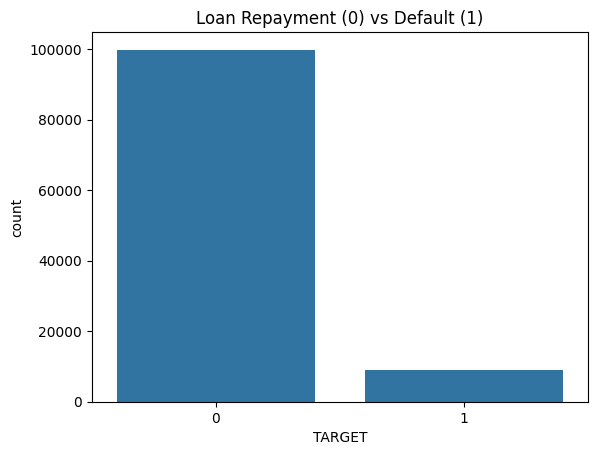

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# (We'll use a subset if memory is an issue, but let's try the full file first)
df = pd.read_csv('application_train.csv')

# 2. Check the TARGET distribution
print("--- Target Distribution ---")
print(df['TARGET'].value_counts())
print("\nPercentage of Default (1) vs Repaid (0):")
print(df['TARGET'].value_counts(normalize=True) * 100)

# 3. Check for Missing Values
# In banking data, missing values often mean the info wasn't provided (High Risk)
missing = df.isnull().sum().sort_values(ascending=False)
percent_missing = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([missing, percent_missing], axis=1, keys=['Total', 'Percent'])

print("\n--- Top 10 Columns with Missing Data ---")
print(missing_data.head(10))

# 4. Visualize the Target Imbalance
sns.countplot(x='TARGET', data=df)
plt.title('Loan Repayment (0) vs Default (1)')
plt.show()

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 1. Selection of powerful features
# These EXT_SOURCE columns are usually the best predictors of risk
features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'DAYS_BIRTH']
X = df[features]
y = df['TARGET']

# 2. Handling Missing Values (Imputation)
# We fill missing values with the median to avoid outliers affecting the mean
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# 3. Scaling
# Logistic Regression needs features on the same scale to converge correctly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 4. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 5. Train Baseline Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# 6. Predict
y_pred = log_reg.predict(X_test)
print("--- Baseline Classification Report ---")
print(classification_report(y_test, y_pred))

--- Baseline Classification Report ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     19960
           1       0.43      0.00      0.00      1772

    accuracy                           0.92     21732
   macro avg       0.67      0.50      0.48     21732
weighted avg       0.88      0.92      0.88     21732



In [3]:
# 1. Get probabilities instead of hard 0 or 1
# This gives a score between 0 and 1
y_probs = log_reg.predict_proba(X_test)[:, 1]

# 2. Define Business Costs
cost_fp = 500   # Lost profit from rejecting a good client
cost_fn = 5000  # Lost money from a defaulter

def calculate_business_cost(threshold):
    # If probability > threshold, we predict Default (1)
    y_tuned_pred = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_tuned_pred).ravel()
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    return total_cost

# 3. Test different thresholds to find the minimum cost
thresholds = np.linspace(0, 0.5, 50)
costs = [calculate_business_cost(t) for t in thresholds]

# 4. Find the best threshold
best_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)

print(f"Optimal Threshold: {best_threshold:.2f}")
print(f"Minimum Business Cost: ${min_cost:,}")

# 5. Final Report with the new threshold
y_final_pred = (y_probs >= best_threshold).astype(int)
print("\n--- Optimized Classification Report ---")
print(classification_report(y_test, y_final_pred))

Optimal Threshold: 0.08
Minimum Business Cost: $6,208,500

--- Optimized Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.68      0.80     19960
           1       0.16      0.66      0.25      1772

    accuracy                           0.68     21732
   macro avg       0.56      0.67      0.52     21732
weighted avg       0.89      0.68      0.75     21732



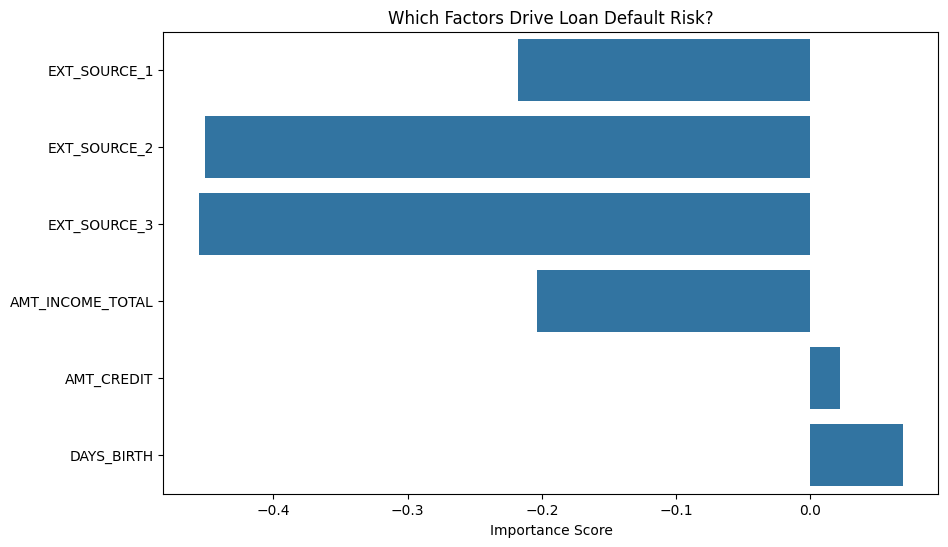

In [4]:
# Feature Importance for Logistic Regression
importance = log_reg.coef_[0]
feature_names = features

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importance, y=feature_names)
plt.title('Which Factors Drive Loan Default Risk?')
plt.xlabel('Importance Score')
plt.show()